# M1 — Analiza dataseta (EDA)

**Tema 28 — Simulacija autonomnog vozila (Unity ML-Agents)**

Ovaj notebook ide **korak po korak**. Uz svaku ćeliju ide objašnjenje: *šta* radimo i *zašto*. Cilj M1:

1. **Provjeriti format** dataseta i **dokazati šta je koja kolona** (dataset nema header).
2. Izračunati **statistiku** vožnje (steering, brzina, glatkoća).
3. Prilagoditi **teoretsku raspodjelu** steeringu i testirati je (χ²).
4. Izvesti **konkretne brojeve** za Unity (§4.4/§4.5 u DESIGN.md).

Dataset: Udacity self-driving-car simulator (`zaynena/selfdriving-car-simulator`), lokalno pod `dataset/` (nije u gitu).

## Mali pojmovnik (za svaki slučaj)

- **Dataset bez headera** — CSV nema prvi red sa imenima kolona; sami moramo znati koja je koja.
- **steering** — ugao volana, ~[-1, 1]; negativno = lijevo, 0 = pravo, pozitivno = desno.
- **integritet** — svaki red ima svoje 3 slike na disku (`redova × 3 == slika`).
- **fingerprint (otisak)** — statistika kolone (min, max, % neg, % nula) iz koje *zaključimo* šta je.
- **deskriptivna statistika** — sažetak uzorka: sredina (mean), disperzija (varijansa), min/max, percentili.
- **disperzija (varijansa)** — koliko su vrijednosti raširene oko sredine (veće = raštrkanije).
- **percentil P95** — vrijednost ispod koje je 95% podataka.
- **Δsteering** — promjena volana od reda do reda; mjeri glatkoću (mali Δ = glatko).
- **raspodjela / fit** — teoretska kriva (npr. normalna) prilagođena obliku podataka.
- **χ² test saglasnosti** — brojka + odluka: da li kriva dobro opisuje podatke (prihvati/odbaci).
- **KS test** — druga provjera istog, bez binova; **D** = najveći razmak stvarne i teoretske krive.
- **zero-inflation** — gomila tačno-nula vrijednosti (kod nas: prava vožnja, steering=0).

## Priprema

Učitavamo naš paket `python/eda` i biblioteke za crtanje. `sys.path` red osigurava da notebook nađe paket bez obzira odakle je pokrenut.

In [1]:
import sys
from pathlib import Path

_here = Path.cwd()
REPO_ROOT = next(p for p in [_here, *_here.parents] if (p / "python" / "eda").exists())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as sp_stats

from python.eda import config
from python.eda.loader import load_track, check_integrity
from python.eda.fingerprint import column_fingerprints
from python.eda import stats as eda_stats

plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.grid"] = True
print("Repo root:", REPO_ROOT)

Repo root: C:\Users\User\Development\RMS


# Sekcija 1 — Format i identitet kolona

## Korak 1 — Učitaj podatke

Tri izvora: `track1` (lakša staza), `track2` (teža, planinska), `combined` (obje spojene). Primarno analiziramo **combined**. CSV je bez headera, pa mu `load_track` sam dodijeli imena kolona (koja dokazujemo u Koraku 3).

In [2]:
ds = load_track("combined")
print(f"Oblik tabele: {ds.df.shape[0]:,} redova x {ds.df.shape[1]} kolona")
ds.df.head()

Oblik tabele: 32,443 redova x 7 kolona


,center,left,right,steering,throttle,brake,speed
0,Desktop\track1data\IMG\center_2019_04_02_19_25...,Desktop\track1data\IMG\left_2019_04_02_19_25_3...,Desktop\track1data\IMG\right_2019_04_02_19_25_...,0.0,0.000000,0.0,0.000011
1,Desktop\track1data\IMG\center_2019_04_02_19_25...,Desktop\track1data\IMG\left_2019_04_02_19_25_3...,Desktop\track1data\IMG\right_2019_04_02_19_25_...,0.0,0.000000,0.0,0.000007
2,Desktop\track1data\IMG\center_2019_04_02_19_25...,Desktop\track1data\IMG\left_2019_04_02_19_25_3...,Desktop\track1data\IMG\right_2019_04_02_19_25_...,0.0,0.000000,0.0,0.000003
3,Desktop\track1data\IMG\center_2019_04_02_19_25...,Desktop\track1data\IMG\left_2019_04_02_19_25_3...,Desktop\track1data\IMG\right_2019_04_02_19_25_...,0.0,0.048016,0.0,0.002267
4,Desktop\track1data\IMG\center_2019_04_02_19_25...,Desktop\track1data\IMG\left_2019_04_02_19_25_3...,Desktop\track1data\IMG\right_2019_04_02_19_25_...,0.0,0.281203,0.0,0.175589


Prve tri kolone su **putanje slika** (`Desktop\...\IMG\...`), zadnje četiri su **brojevi**. Putanje su sa tuđe mašine — svodimo ih na ime fajla + lokalni `IMG/` folder.

## Korak 2 — Provjera integriteta

Svaki red mora imati svoje 3 slike, pa `redova × 3 == broj .jpg u IMG/`. `unresolved_rows` broji redove kojima fali slika. Ovo je **kapija M1**.

In [3]:
for name in ("track1", "track2", "combined"):
    print(check_integrity(load_track(name)).summary())

[track1] rows=10,615 images=31,845 expected=31,845 -> OK; unresolved_rows=0 (sample 0/500)

[track2] rows=21,828 images=65,484 expected=65,484 -> OK; unresolved_rows=0 (sample 0/500)


[combined] rows=32,443 images=97,329 expected=97,329 -> OK; unresolved_rows=0 (sample 0/500)


## Korak 3 — Šta je koja kolona? (dokaz, ne pretpostavka)

Bez headera **ne vjerujemo naslijepo** redoslijedu. Gledamo otisak svake brojčane kolone:

- **steering** — jedina ide u minus (volan lijevo).
- **speed** — nenegativna, ali velike vrijednosti (preko 1).
- **brake** — [0,1] kolona koja je skoro sva nula.
- **throttle** — preostala [0,1] kolona sa pozitivnim vrijednostima.

`slaze se = True` znači zaključak iz statistike = pretpostavljeno ime (Udacity redoslijed potvrđen).

In [4]:
fps = column_fingerprints(ds)
fp_table = pd.DataFrame(
    [
        {
            "kolona": fp.column_index,
            "pretpostavka": fp.assumed_name,
            "zakljucak": fp.inferred_identity,
            "min": round(fp.minimum, 3),
            "max": round(fp.maximum, 3),
            "% neg": round(fp.pct_negative, 1),
            "% nula": round(fp.pct_zero, 1),
            "slaze se": fp.matches_assumption,
        }
        for fp in fps
    ]
)
fp_table

,kolona,pretpostavka,zakljucak,min,max,% neg,% nula,slaze se
0,4,steering,steering,-1.0,1.000,23.5,58.6,True
1,5,throttle,throttle,0.0,1.000,0.0,50.6,True
2,6,brake,brake,0.0,1.000,0.0,94.6,True
3,7,speed,speed,0.0,21.949,0.0,0.0,True


### Vizuelni dokaz (dva panela)

Lijevo: **% negativnih i % nula** — *steering* jedini negativan, *brake* skoro sve nule. Ali speed po tome izgleda prazan (ni negativan, ni nula), pa desno crtamo **raspon (max)** — tu speed "iskoči" (velika magnituda). Svaka kolona prepoznata po SVOJOJ osobini.

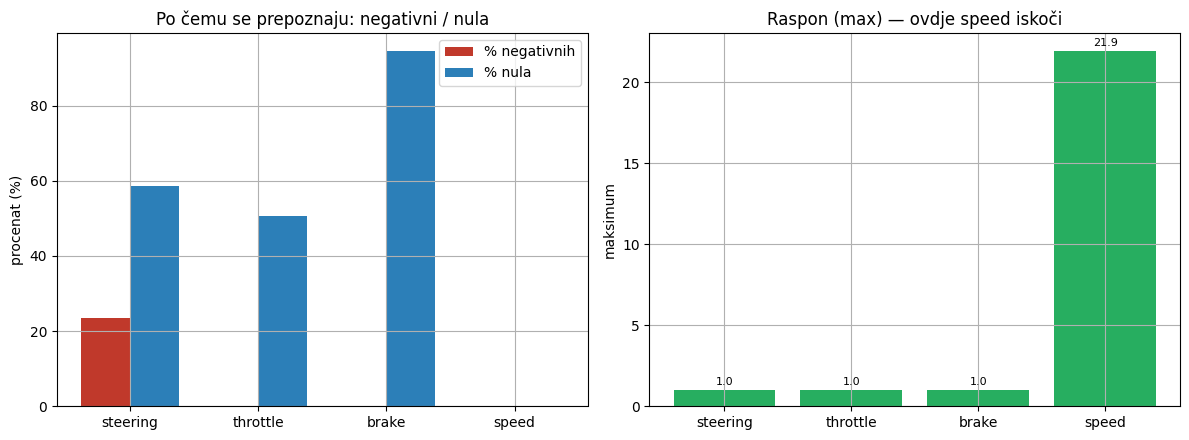

In [5]:
labels = [fp.inferred_identity for fp in fps]
pct_neg = [fp.pct_negative for fp in fps]
pct_zero = [fp.pct_zero for fp in fps]
maxes = [fp.maximum for fp in fps]
x = np.arange(len(labels))
w = 0.38

fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.5))
axL.bar(x - w / 2, pct_neg, w, label="% negativnih", color="#c0392b")
axL.bar(x + w / 2, pct_zero, w, label="% nula", color="#2c7fb8")
axL.set_xticks(x); axL.set_xticklabels(labels); axL.set_ylabel("procenat (%)")
axL.set_title("Po čemu se prepoznaju: negativni / nula"); axL.legend()

axR.bar(x, maxes, color="#27ae60")
axR.set_xticks(x); axR.set_xticklabels(labels); axR.set_ylabel("maksimum")
axR.set_title("Raspon (max) — ovdje speed iskoči")
for i, m in enumerate(maxes):
    axR.text(i, m + 0.3, f"{m:.1f}", ha="center", fontsize=8)
plt.tight_layout(); plt.show()

# Sekcija 2 — Deskriptivna statistika

## Korak 4 — Sažetak brojeva

Za tri veličine računamo: obim uzorka, **sredinu** (matematičko očekivanje), **disperziju** (varijansu) i **std**, min/max i percentile.

- **steering** — stil vožnje.
- **speed** — brzina.
- **|Δsteering|** — glatkoća: koliko se volan trza. **Računa se po stazi** (nikad preko spoja track1→track2), da ne izmislimo lažan skok.

In [6]:
t1, t2 = load_track("track1"), load_track("track2")
abs_delta = eda_stats.abs_delta_steering([t1, t2])  # po stazi, pa spojeno

summaries = {
    "steering": eda_stats.describe(ds.df["steering"], "steering"),
    "speed": eda_stats.describe(ds.df["speed"], "speed"),
    "|delta steering|": eda_stats.describe(abs_delta, "|delta steering|"),
}
desc_table = pd.DataFrame(
    [
        {
            "varijabla": s.variable,
            "n": s.n,
            "mean": round(s.mean, 4),
            "disperzija": round(s.variance, 4),
            "std": round(s.std, 4),
            "min": round(s.minimum, 3),
            "max": round(s.maximum, 3),
            "P50": round(s.percentiles[50], 3),
            "P95": round(s.percentiles[95], 3),
            "P99": round(s.percentiles[99], 3),
        }
        for s in summaries.values()
    ]
)
desc_table

,varijabla,n,mean,disperzija,std,min,max,P50,P95,P99
0,steering,32443,-0.0209,0.1515,0.3892,-1.0,1.000,0.00,0.800,1.000
1,speed,32443,10.2114,10.6855,3.2689,0.0,21.949,10.25,15.275,17.486
2,|delta steering|,32441,0.1112,0.0385,0.1963,0.0,1.000,0.00,0.550,1.000


## Korak 5 — Histogrami

Histogram = slika raspodjele (gdje se podaci gomilaju). Na |Δsteering| crtamo i **P95 liniju** = prag iznad kojeg je promjena volana "nagla" (ide u reward, DESIGN §4.5). Rep je dug pa koristimo log skalu da bude vidljiv.

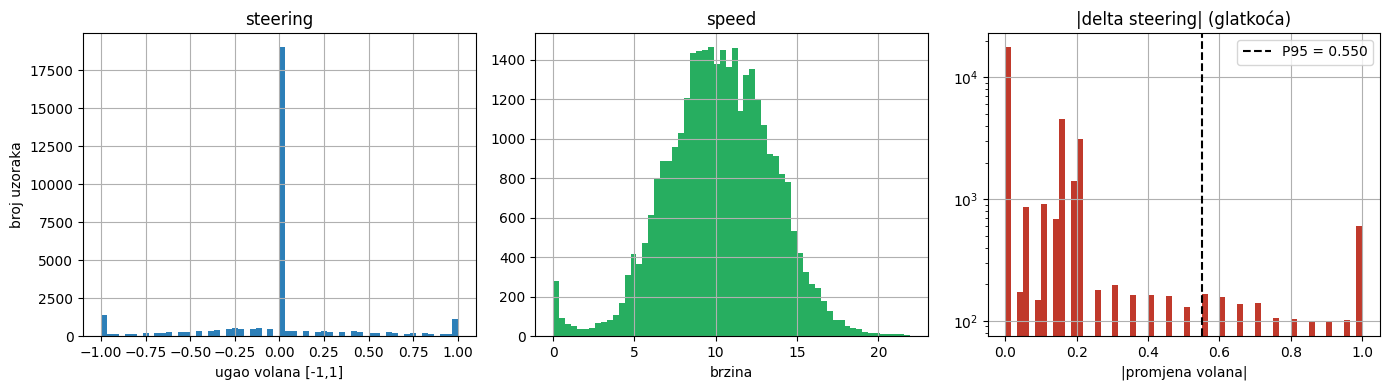

Prag nagle promjene volana (P95 od |delta steering|): 0.550


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(ds.df["steering"], bins=60, color="#2c7fb8")
axes[0].set_title("steering"); axes[0].set_xlabel("ugao volana [-1,1]"); axes[0].set_ylabel("broj uzoraka")

axes[1].hist(ds.df["speed"], bins=60, color="#27ae60")
axes[1].set_title("speed"); axes[1].set_xlabel("brzina")

p95 = np.percentile(abs_delta, config.DELTA_STEERING_PERCENTILE)
axes[2].hist(abs_delta, bins=60, color="#c0392b")
axes[2].axvline(p95, color="black", linestyle="--", label=f"P95 = {p95:.3f}")
axes[2].set_title("|delta steering| (glatkoća)"); axes[2].set_xlabel("|promjena volana|"); axes[2].legend()
axes[2].set_yscale("log")
plt.tight_layout(); plt.show()
print(f"Prag nagle promjene volana (P95 od |delta steering|): {p95:.3f}")

## Korak 6 — track1 vs track2

track1 je ravna (lakša), track2 planinska (oštre krivine). Očekujemo da track2 ima **širi** steering (više punog zaokreta).

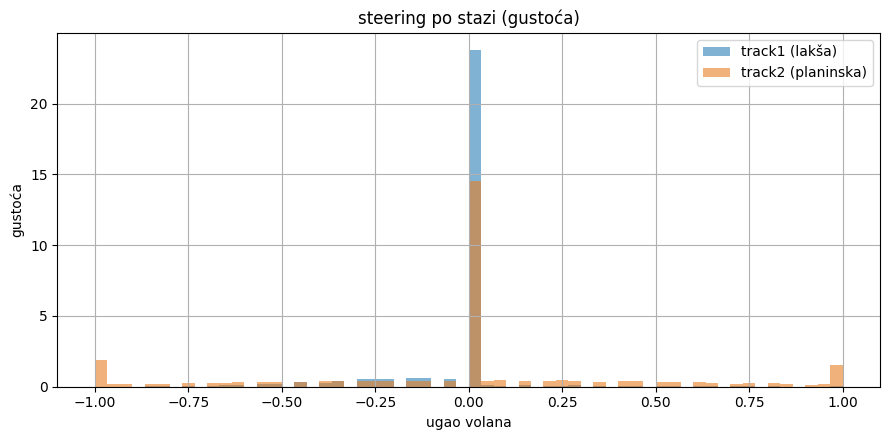

track1: std=0.155  P95=0.000  udio nula=79.3%
track2: std=0.462  P95=1.000  udio nula=48.4%


In [8]:
fig, ax = plt.subplots()
ax.hist(t1.df["steering"], bins=60, alpha=0.6, density=True, label="track1 (lakša)", color="#2c7fb8")
ax.hist(t2.df["steering"], bins=60, alpha=0.6, density=True, label="track2 (planinska)", color="#e67e22")
ax.set_title("steering po stazi (gustoća)"); ax.set_xlabel("ugao volana"); ax.set_ylabel("gustoća"); ax.legend()
plt.tight_layout(); plt.show()
for nm, tds in (("track1", t1), ("track2", t2)):
    s = eda_stats.describe(tds.df["steering"], nm)
    zero_pct = (tds.df['steering'] == 0).mean() * 100
    print(f"{nm}: std={s.std:.3f}  P95={s.percentiles[95]:.3f}  udio nula={zero_pct:.1f}%")

# Sekcija 3 — Prilagođavanje raspodjele + χ² test

## Korak 7 — Fit + test saglasnosti

Steering nije obična kontinualna veličina — ima **tri tačkasta špica**:

- **0** = prava vožnja (velik udio),
- **-1** = puni lijevi zaokret (zasićenje),
- **+1** = puni desni zaokret (zasićenje).

Nijedna glatka kriva ne opisuje špiceve, pa ih brojimo **posebno** (kao vjerovatnoće) i fitujemo samo **kontinualni interior** (sve strogo između, bez 0 i bez ±1).

Postupak: fit 3 kandidata (normalna/laplace/uniformna) na interior → rangiraj po AIC → χ² test pobjednika (+ KS). Rezultat *može* biti "odbaci" — validan nalaz.

In [9]:
res = eda_stats.fit_steering(ds.df["steering"])
print("Tačkaste mase (mješavina):")
print(f"  0  (pravo)      : {res.zero_mass*100:5.1f}%")
print(f"  -1 (puni lijevo): {res.sat_neg_mass*100:5.1f}%")
print(f"  +1 (puni desno) : {res.sat_pos_mass*100:5.1f}%")
print(f"  interior (fit)  : {res.interior_mass*100:5.1f}%")
print()
aic_table = pd.DataFrame(
    [{"raspodjela": k, "AIC (manji=bolji)": round(v, 0)} for k, v in res.aic_ranking.items()]
).sort_values("AIC (manji=bolji)").reset_index(drop=True)
print("AIC rangiranje (na interioru):")
print(aic_table.to_string(index=False))
print()
print(f"Pobjednik po AIC: {res.dist_name}  params={tuple(round(p,4) for p in res.params)}")
print(f"chi2 test: stat={res.chi2_stat:.1f}  dof={res.dof}  kriticno={res.chi2_critical:.1f}  p={res.chi2_pvalue:.3g}")
print(f"Odluka:    {'ODBACI (ne fituje)' if res.reject_null else 'PRIHVATI (fituje)'} na alpha={res.alpha}")
print(f"KS test:   D={res.ks_stat:.4f}  p={res.ks_pvalue:.3g}")

Tačkaste mase (mješavina):
  0  (pravo)      :  58.6%
  -1 (puni lijevo):   4.2%
  +1 (puni desno) :   3.4%
  interior (fit)  :  33.8%

AIC rangiranje (na interioru):
raspodjela  AIC (manji=bolji)
   uniform            14079.0
      norm            14602.0
   laplace            16498.0

Pobjednik po AIC: uniform  params=(-0.95, 1.9)
chi2 test: stat=2710.6  dof=27  kriticno=40.1  p=0
Odluka:    ODBACI (ne fituje) na alpha=0.05
KS test:   D=0.0961  p=1.46e-88


## Korak 8 — Vizuelno: interior vs fitovane krive

Crtamo histogram **interiora** (bez špiceva na 0 i ±1) i preko njega tri fitovane krive. Sad se vidi stварни oblik kontinualnog dijela — raširen preko opsega, pa uniform (ravna) ima najbolji AIC, ali χ² svejedno odbacuje (nije savršeno ravan).

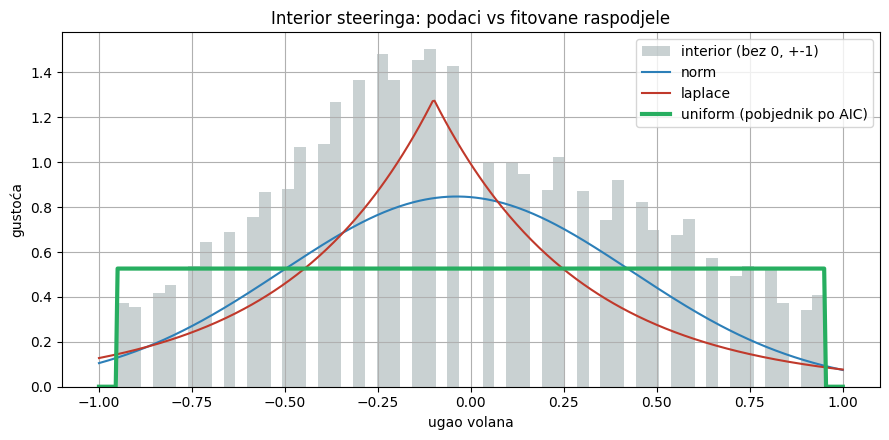

In [10]:
body = eda_stats.steering_interior(ds.df["steering"])  # bez 0 i bez +-1
xg = np.linspace(-1, 1, 400)

fig, ax = plt.subplots()
ax.hist(body, bins=60, density=True, alpha=0.5, color="#95a5a6", label="interior (bez 0, +-1)")
colors = {"norm": "#2c7fb8", "laplace": "#c0392b", "uniform": "#27ae60"}
for name in config.STEERING_FIT_CANDIDATES:
    dist = getattr(sp_stats, name)
    params = dist.fit(body)
    lw = 3 if name == res.dist_name else 1.5
    tag = " (pobjednik po AIC)" if name == res.dist_name else ""
    ax.plot(xg, dist.pdf(xg, *params), color=colors[name], lw=lw, label=name + tag)
ax.set_title("Interior steeringa: podaci vs fitovane raspodjele")
ax.set_xlabel("ugao volana"); ax.set_ylabel("gustoća"); ax.legend()
plt.tight_layout(); plt.show()

# Sekcija 4 — Kalibracija za Unity

## Korak 9 — Izvuci konkretne brojeve za M2

Funkcija `run_m1()` pokrene cijelu analizu i vrati **kalibracione vrijednosti** koje predajemo Unity fazi (M2). Usput sačuva grafike u `results/plots/`, izvještaj `results/eda/m1_report.md` i mašinski `results/eda/m1_stats.json`.

Šta koji broj hrani:

- **steering raspon** → DESIGN §4.4 (opseg akcije volana, mapiranje na ±°).
- **prag |Δsteering| (P95)** → DESIGN §4.5 (kazna za nagli trzaj volana).
- **raspon brzine** → podešavanje okruženja (tipične brzine).
- **brake %nula** → napomena: koliko je kolona korištena.

In [11]:
from python.eda.report import run_m1
import dataclasses

calib = run_m1()  # pokrene sve + sačuva artefakte u results/
pd.DataFrame([{'parametar': k, 'vrijednost': v} for k, v in dataclasses.asdict(calib).items()])

,parametar,vrijednost
0,steering_range_raw,"(-1.0, 1.0)"
1,steering_range_robust,"(-1.0, 1.0)"
2,delta_steering_threshold,0.55
3,speed_range,"(3.474659e-06, 17.486463799999996)"
4,steering_zero_pct,58.555004
5,brake_zero_pct,94.615171
6,brake_is_dead,False


**Čitanje rezultata:**

- `steering_range_robust` (P1–P99) je jednak sirovom (−1, 1) → volan **koristi puni opseg** (track2 ima mnogo punog zaokreta), pa je mapiranje ±1 → ±25° u Unityju opravdano podacima.
- `delta_steering_threshold` (P95) → iznad ove promjene volana reward kažnjava trzaj.
- `brake_is_dead=False`, ali ~95% nula → kočnica se rijetko koristi (bitno za dizajn akcija).

Ovi brojevi se prepisuju u DESIGN §4.4/§4.5 (sljedeći korak, van notebooka).

## Zaključak M1 (dosad)

- **Format i kolone** potvrđeni statistički (Sekcija 1).
- **Deskriptivna statistika**: steering centriran oko 0, dominira prava vožnja; track2 ima širi steering od track1.
- **Raspodjela**: steering je **zero-inflated** (velik udio tačnih nula) + zasićenje na ±1 (puni zaokret). χ² **odbacuje** standardne raspodjele — ljudski steering ne prati jednostavnu krivu; koristimo **empirijsku raspodjelu** kao referencu (baš to poredimo sa RL/BC agentima u M5).
- **Kalibracija za Unity** (DESIGN §4.4/§4.5): raspon steeringa, prag |Δsteering| (P95), tipičan raspon brzine — izvlačimo u sljedećem koraku (US3).

> Taksonomija za odbranu: model je stohastički, kontinualnih stanja, diskretnog vremena, agentski — a steering je nedeterministička veličina koju smo statistički okarakterizovali.

# Sekcija 5 — Autentičnost podataka („friziranje podataka")

Do sada smo pitali **šta podaci kažu**. Sada pitamo nešto drugo:

> **Da li su podaci uopšte ono za šta se izdaju?**

„Friziranje podataka" je namjerno ili slučajno mijenjanje dataseta tako da izgleda bolje,
urednije ili poželjnije nego što jeste. Nekoliko tipičnih načina:

| Šta se uradi | Zašto neko to radi |
|---|---|
| izbace se loši snimci (sudari, izlijetanja) | model izgleda bolji nego što jeste |
| iskopira se dobar dio i doda na kraj | dataset izgleda veći |
| zalijepe se dva snimka u jedan | isto — veći dataset |
| ručno se „poprave" vrijednosti | krive izgledaju glađe |

**Ključno pravilo cijele ove sekcije:**

> ### Bez nulte hipoteze nema nalaza.
>
> Gola brojka ne dokazuje ništa. Prije nego što smijemo bilo šta prijaviti kao sumnjivo,
> moramo unaprijed reći **kako bi podaci izgledali da je manipulacija urađena**. To se zove
> *očekivani potpis*. Bez njega izvještaj je samo lista strašnih brojeva.

I obratna strana, koja je jednako važna:

> ### Lažna uzbuna je jednako ozbiljna greška kao propušten nalaz.
>
> Ako provjera proglasi **ispravan** dataset frizuranim, to nije „oprez" — to je greška koja
> obara cijeli projekat. Zato svaka provjera ovdje ima **dva** testa: mora uhvatiti namjerno
> pokvarene podatke *i* mora ćutati na ispravnim.

## Dopuna pojmovnika (samo za ovu sekciju)

- **H₀ (nulta hipoteza)** — tvrdnja koju testiramo, uvijek u obliku „nema efekta, sve je kako
  očekujemo". Test može samo **odbaciti** H₀ ili **ne odbaciti** — nikad je *dokazati*.
- **Očekivani potpis** — kako bi podaci izgledali *da* je manipulacija urađena.
- **Sesija (snimak)** — jedno neprekinuto snimanje. Vrijeme ima smisla samo unutar sesije.
- **Rešetka (lattice)** — pravilna mreža dozvoljenih vrijednosti, npr. …, −0.10, −0.05, 0.00,
  0.05, … Razmak između njih je **korak**.
- **Diskretna vs kontinualna** — diskretna ima konačan skup mogućih vrijednosti (rešetka),
  kontinualna može biti bilo koji realan broj.
- **Pogrešna specifikacija modela** — kad na podatke primijeniš model koji po svojoj prirodi
  ne može odgovarati (npr. glatka kriva na rešetkaste podatke). Test tada odbacuje model, ali
  to ne govori ništa o podacima — govori o modelu. *Ovo nam se desilo u Sekciji 3.*
- **MAD (median absolute deviation)** — robusna mjera rasipanja. Za razliku od standardne
  devijacije, nekoliko ekstremnih vrijednosti je ne pokvari.

In [12]:
from python.eda.integrity import (
    split_sessions, parse_capture_times, check_timeline, check_duplicates,
    check_plausibility, profile_granularity, implied_acceleration,
)
from python.eda import authenticity as auth

# Moduli koji pišu figure na disk (python.eda.report u Sekciji 4, i authenticity iznad)
# prebacuju matplotlib na "Agg" — backend bez prozora, da bi radili i u skripti bez ekrana.
# Nuspojava je da grafici prestanu da se crtaju u samom notebooku. Zato backend vraćamo na
# inline OVDJE, poslije importa — magija prije importa bi bila pregažena.
%matplotlib inline

t1, t2 = load_track("track1"), load_track("track2")
combined = load_track("combined")
print("Učitano:", {d.name: len(d.df) for d in (t1, t2, combined)})

Učitano: {'track1': 10615, 'track2': 21828, 'combined': 32443}


## 5.1 — Porijeklo i cjelovitost snimka

### Korak 10 — Zašto baš vrijeme?

Svaka slika u datasetu nosi vrijeme snimanja **u svom imenu**:

```
center_2019_04_02_19_25_33_671.jpg
       └─ 2019-04-02, 19:25:33.671 ─┘
```

Vrijeme je najteža stvar za lažirati, i to iz jednog razloga: ono mora biti **konzistentno sa
samim sobom**. Ako neko izbaci 50 redova iz sredine, brojke u koloni `steering` i dalje
izgledaju savršeno normalno — ali u vremenu ostane **rupa** koju je nemoguće ne vidjeti. Ako
neko izmiješa redove da „sakrije" nešto, vrijeme prestane teći naprijed.

Zato krećemo odavde.

### Korak 11 — Prva zamka: gdje se smije mjeriti vrijeme

Prije nego što išta izmjerimo, moramo znati **gdje jedan snimak prestaje**.

Spojeni fajl (`combined`) nije jedno snimanje — to su dva snimka zalijepljena jedan za drugim.
I sad dolazi detalj koji lako obori naivnu provjeru:

> **Staza 2 je snimljena RANIJE istog dana nego staza 1.**
> Ali u spojenom fajlu track1 dolazi prvi.

Dakle na spoju vrijeme **ide unazad za oko 80 minuta**. Naivna provjera bi to prijavila kao
ogromnu anomaliju i „otkrila friziranje" u savršeno ispravnom datasetu.

Sesiju izvlačimo iz **putanje slike** (`Desktop\track1data\...` vs `Desktop\track2data\...`) i
sve vremenske provjere radimo **po sesiji**.

In [13]:
for s in split_sessions(combined):
    print(f"{s.session_id:>11}  redovi {s.start_index:>6}–{s.end_index:<6} "
          f"({s.n_rows:>6,})   {s.start_time}  →  {s.end_time}")

a, b = split_sessions(combined)
print()
print("Redoslijed po REDOVIMA :", a.session_id, "prije", b.session_id)
print("Redoslijed po VREMENU  :", (b if b.start_time < a.start_time else a).session_id, "prije",
      (a if b.start_time < a.start_time else b).session_id)
print("→ Redoslijed redova i redoslijed vremena SE NE POKLAPAJU. Otud zamka.")

 track1data  redovi      0–10614  (10,615)   2019-04-02 19:25:33.671000  →  2019-04-02 19:38:12.752000


 track2data  redovi  10615–32442  (21,828)   2019-04-02 18:05:37.641000  →  2019-04-02 18:31:04.870000



Redoslijed po REDOVIMA : track1data prije track2data
Redoslijed po VREMENU  : track2data prije track1data
→ Redoslijed redova i redoslijed vremena SE NE POKLAPAJU. Otud zamka.


### Korak 12 — Kontinuitet: monotonost, razmak, rupe

Tri stvari mjerimo po sesiji, i svaka ima svoj očekivani potpis:

| Provjera | Šta hvata | Očekivani potpis |
|---|---|---|
| **monotonost** | izmiješane redove | vrijeme prestaje teći naprijed |
| **rupe (gaps)** | izrezan blok | **jedna velika** rupa |
| **raspodjela Δt** | brisanje pojedinačnih redova | **mnogo malih** rupa oko 2× medijana |

**Odakle prag za rupu?** Ne pogađamo ga — izvodimo ga iz podataka:

$$\text{rupa} \iff \Delta t > 5 \times \text{median}(\Delta t)$$

Pri ~14 kadrova/s (median Δt ≈ 0.07 s), 5× median znači da je propušteno oko 4–5 uzastopnih
kadrova. Jedan preskočen kadar je normalno opterećenje simulatora; pet uzastopnih je događaj.
Pošto je prag vezan za medijan, sam se prilagodi ako se brzina snimanja razlikuje po stazi —
dakle to je **pravilo**, a ne magičan broj.

In [14]:
rows = []
for ds in (t1, t2):
    for r in check_timeline(ds):
        rows.append({
            "sesija": r.session_id, "redova": r.n_rows,
            "monotono": "da" if r.is_monotonic else "NE",
            "narušenja": r.n_order_violations,
            "median Δt": round(r.median_interval_s, 4),
            "kadrova/s": round(r.implied_fps, 2),
            "prag rupe": round(r.gap_threshold_s, 3),
            "rupa": r.n_gaps, ">2×": r.gap_tiers[">2x"], ">1 s": r.gap_tiers[">1s"],
            "najveća": round(r.largest_gap_s, 3),
            "neparsiranih": r.n_unparseable,
        })
pd.DataFrame(rows)

,sesija,redova,monotono,narušenja,median Δt,kadrova/s,prag rupe,rupa,>2×,>1 s,najveća,neparsiranih
0,track1data,10615,da,0,0.071,14.08,0.355,1,1,0,0.474,0
1,track2data,21828,da,0,0.070,14.29,0.350,0,2,0,0.253,0


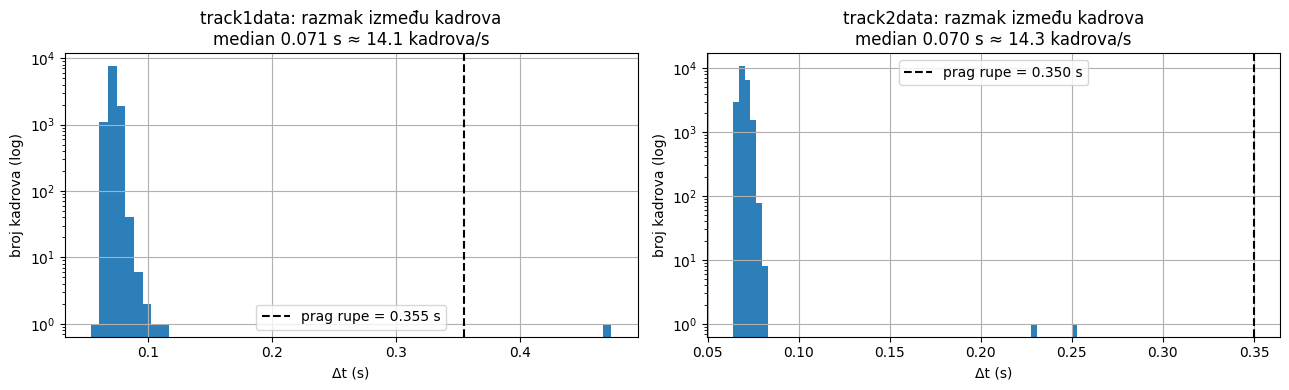

In [15]:
# Cijela raspodjela razmaka, ne samo maksimum — jer oblik repa razlikuje jedno veliko
# rezanje od mnogo sitnih brisanja. Y-osa je logaritamska: rep je ovdje cijela poenta.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, ds in zip(axes, (t1, t2)):
    rep = check_timeline(ds)[0]
    times, _ = parse_capture_times(ds)
    dt = times.diff().dropna().dt.total_seconds()
    ax.hist(dt, bins=60, color="#2c7fb8")
    ax.axvline(rep.gap_threshold_s, color="black", ls="--",
               label=f"prag rupe = {rep.gap_threshold_s:.3f} s")
    ax.set_yscale("log")
    ax.set_title(f"{rep.session_id}: razmak između kadrova\n"
                 f"median {rep.median_interval_s:.3f} s ≈ {rep.implied_fps:.1f} kadrova/s")
    ax.set_xlabel("Δt (s)"); ax.set_ylabel("broj kadrova (log)"); ax.legend()
fig.tight_layout(); plt.show()

**Čitanje rezultata.**

- Obje sesije su **monotone**, 0 narušenja → nijedan red nije premješten.
- 0 neparsiranih vremenskih oznaka → **nijedan red nije tiho izbačen** iz analize. (Ovo je
  namjerno izvještavano: provjera koja tiho odbaci redove koje ne razumije može „ne naći
  ništa" upravo zato što je izbacila dokaz.)
- track1 ima **jednu** rupu iznad praga (0.474 s ≈ 6 kadrova). Nije `> 1 s`.
  Da li je to trag rezanja? Vidjećemo u 5.3 — pogledaćemo **gdje** ta rupa pada.
- track2: nijedna rupa iznad praga.

Oblik histograma je uzak vrh oko 0.07 s sa tankim repom — tako izgleda snimanje pod
promjenljivim opterećenjem. Da je neko brisao pojedinačne „ružne" redove, vidjeli bismo
**gomilu** vrijednosti oko 0.14 s (= 2× median), a ne pojedinačne izlete.

### Korak 13 — Duplikati: tri različite stvari, tri odvojena broja

Ovo je mjesto gdje se najlakše napravi lažna uzbuna. Postoje **tri** vrste ponavljanja i
znače potpuno različite stvari:

| # | Vrsta | Šta znači |
|---|---|---|
| 1 | **identičan cijeli red** | kopiranje redova radi naduvavanja veličine → **potpis manipulacije** |
| 2 | **ponovljena putanja slike** | isti kadar upisan više puta → **potpis manipulacije** |
| 3 | **ponovljena četvorka mjerenja** (steering, throttle, brake, speed) uz **različitu** sliku | **očekivano i bezopasno** |

Zašto je (3) bezopasno? Zato što steering ima samo **41 mogući nivo**. Prostor vrijednosti je
mali, pa se sudari dešavaju sami od sebe — kao rođendani u razredu.

Da ova tri broja saberemo u jedan „broj duplikata", (3) bi maskirao (1) i (2), i dobili bismo
uzbunu tamo gdje je nema.

In [16]:
pd.DataFrame([{
    "izvor": r.source,
    "1. identični redovi": r.n_exact_duplicate_rows,
    "2. ponovljene slike": r.n_duplicate_image_refs,
    "3. ponovljene četvorke": r.n_duplicate_measurement_tuples,
} for r in (check_duplicates(t1), check_duplicates(t2))])

,izvor,1. identični redovi,2. ponovljene slike,3. ponovljene četvorke
0,track1,0,0,12
1,track2,0,0,4


**Čitanje.** Vrste 1 i 2 su **nula** na obje staze — nema kopiranih redova ni ponovljenih
kadrova. Vrsta 3 postoji (12 i 4) i to je upravo ono što očekujemo od rešetkaste varijable.
Zaključak: dataset **nije naduvan kopiranjem**.

### Korak 14 — Fizička uvjerljivost: da li se brzina mijenja kako treba?

Između dva susjedna kadra brzina se ne može promijeniti proizvoljno mnogo. Računamo
**implicirano ubrzanje**:

$$a = \frac{\Delta \text{speed}}{\Delta t}$$

**Zašto ne kažemo apsolutnu granicu (npr. „ispod 1 g")?** Zato što jedinica kolone `speed` u
Udacity formatu **nije dokumentovana** — ne znamo da li su m/s, mph ili interne jedinice.
Tvrdnja o 1 g tražila bi pretpostavku koju ne možemo provjeriti, a **lažna preciznost je gora
od poštene relativne mjere**. Zato pitamo samo: *koji koraci odudaraju od ostatka istog
snimka?* — što je upravo potpis spajanja ili brisanja redova.

**Zašto MAD, a ne standardna devijacija?** Ovo je najvažniji detalj u koraku, pa ga pokazujemo
uživo umjesto da ga tvrdimo.

In [17]:
# Demonstracija: uzmemo 40 ISPRAVNIH kadrova sa track1 i ubacimo jedan nemoguć skok brzine.
# Onda pitamo dva pravila sa ISTIM množiocem (5) da ga nađu.
demo = t1.df["speed"].to_numpy(float)[:41].copy()
demo[18] = 900.0                      # nemoguća brzina
a = np.diff(demo) / 0.071             # implicirano ubrzanje (median Δt na track1)

med, mad = np.median(a), np.median(np.abs(a - np.median(a)))
mu, sd = a.mean(), a.std(ddof=1)

print(f"MAD pravilo:  |a − {med:8.2f}| > 5 × {mad:8.2f} = {5*mad:10.2f}  →  "
      f"{np.sum(np.abs(a - med) > 5*mad)} outliera")
print(f"σ   pravilo:  |a − {mu:8.2f}| > 5 × {sd:8.2f} = {5*sd:10.2f}  →  "
      f"{np.sum(np.abs(a - mu) > 5*sd)} outliera")
print()
print("Ubačeni skok je naduvao standardnu devijaciju toliko da je granica prešla PREKO njega.")
print("Medijan i MAD ga nisu ni primijetili, pa granica ostaje niska i skok se vidi.")

MAD pravilo:  |a −     1.49| > 5 ×     2.04 =      10.19  →  3 outliera
σ   pravilo:  |a −     2.57| > 5 ×  2852.29 =   14261.45  →  0 outliera

Ubačeni skok je naduvao standardnu devijaciju toliko da je granica prešla PREKO njega.
Medijan i MAD ga nisu ni primijetili, pa granica ostaje niska i skok se vidi.


In [18]:
pd.DataFrame([{
    "sesija": r.session_id,
    "median a": round(r.median_accel, 3),
    "MAD": round(r.mad_accel, 3),
    "max |a|": round(r.max_abs_accel, 2),
    "prag": round(r.outlier_threshold, 2),
    "outliera": r.n_outliers,
    "% redova": round(100 * r.n_outliers / len(ds.df), 2),
} for ds in (t1, t2) for r in check_plausibility(ds)])

,sesija,median a,MAD,max |a|,prag,outliera,% redova
0,track1data,-0.813,1.459,12.81,6.48,796,7.5
1,track2data,-0.133,2.147,25.75,10.60,982,4.5


**Čitanje — i ovdje treba biti pošten.**

Broj outliera je **velik** (7,5 % i 4,5 %). Prva reakcija bi bila panika. Ali pogledajmo šta
smo zapravo izmjerili: raspodjela impliciranog ubrzanja ima **uzak centar i široke repove**
(MAD ≈ 1,5 ali maksimum ≈ 13). Gas i kočnica se pri 14 kadrova/s koriste **u naletima**, pa
pojas od 5×MAD oko uskog centra pada negdje oko 97. percentila — i „hvata" 3 % podataka po
konstrukciji.

Dakle visok procenat je **oblik raspodjele**, a ne trag friziranja.

> **Iskušenje kojem se NE smije podleći:** podesiti množilac sa 5 na, recimo, 30 dok broj
> outliera ne ispadne „lijep". To bi bilo friziranje **naše analize** — namještanje praga da
> dâ željeni odgovor. Prag ostaje 5, a broj se objašnjava.

Prava vrijednost ove provjere nije u broju, nego u **poklapanju**: potpis spajanja dva snimka
bio bi ekstremno ubrzanje **tačno tamo gdje je rupa u vremenu**. Provjerićemo to u 5.3.

## 5.2 — Rezolucija zapisa i ispravno specifikovani testovi

### Korak 15 — Pitanje koje M1 nije postavio

U Sekciji 3 smo na steering prilagođavali **glatke krive** (normalna, Laplace, uniformna) i
χ² ih je sve odbacio (χ² ≈ 2711). Zaključili smo: „ljudski steering ne prati standardnu
raspodjelu".

Zaključak je bio tačan. **Razlog je bio pogrešan.**

Postoji pitanje koje smo preskočili: *koliko fino je varijabla uopšte zapisana?*

In [19]:
v = np.unique(t1.df["steering"].to_numpy(float))
print(f"Koliko RAZLIČITIH vrijednosti steeringa postoji na track1? → {v.size}")
print(f"Za poređenje, speed:                                        → "
      f"{np.unique(t1.df['speed']).size:,}")
print()
print("Prvih 12 vrijednosti steeringa, sortirano:")
print(np.round(v[:12], 7))
print()
print("Razmak između susjednih:")
print(np.round(np.diff(v[:12]), 7))

Koliko RAZLIČITIH vrijednosti steeringa postoji na track1? → 40
Za poređenje, speed:                                        → 10,533

Prvih 12 vrijednosti steeringa, sortirano:
[-1.        -0.9500002 -0.9000002 -0.8500001 -0.8000001 -0.7500002
 -0.7       -0.6500001 -0.6000001 -0.5500001 -0.5000001 -0.45     ]

Razmak između susjednih:
[0.0499998 0.05      0.0500001 0.05      0.0499999 0.0500002 0.0499999
 0.05      0.05      0.05      0.0500001]


Dakle steering **nije kontinualan**. On živi na **rešetki sa korakom 0.05**: 41 dozvoljena
vrijednost od −1.00 do +1.00. Simulator ga tako zapisuje.

**Zašto to sve mijenja.** Glatka kriva (gustina) po svojoj prirodi opisuje varijablu koja može
uzeti bilo koju vrijednost. Ako je primijeniš na varijablu sa 41 dozvoljenom vrijednošću, model
**ne može** odgovarati — bez obzira na podatke. To se zove **pogrešna specifikacija modela**.

> χ² ≈ 2711 iz Sekcije 3 **nije otkriće o podacima. To je svojstvo modela.**
> Test je vjerno prijavio da model ne valja, i bio je u pravu — samo iz drugog razloga nego
> što smo mislili.

Ostavljamo Sekciju 3 u notebooku baš zato: pokazati grešku i ispraviti je jače je nego
pretvarati se da je nije bilo.

### Korak 16 — Detekcija rešetke, i jedna zamka sa decimalama

Kako detektujemo rešetku? Uzmemo sve različite vrijednosti, izračunamo razmake između njih, i
provjerimo je li **svaka vrijednost cijeli umnožak koraka**.

Ali tu vreba zamka: **0.05 se ne može tačno zapisati u binarnom obliku.** Ako tražimo *tačnu*
jednakost, rešetka „nestane" zbog greške zaokruživanja. Zato poredimo unutar **tolerancije**.

I tu smo naletjeli na stvarni nalaz, koji nismo očekivali:

In [20]:
print("Vrijednosti steeringa iznad 0.45, ispisane sa 7 decimala:")
print(np.round(v[v > 0.45], 7))
print()
print("Isti brojevi, minus najbliži nivo rešetke:")
print(np.round(v[v > 0.45] - np.round(v[v > 0.45] / 0.05) * 0.05, 10))

Vrijednosti steeringa iznad 0.45, ispisane sa 7 decimala:
[0.5000001 0.5500001 0.6000001 0.6500001 0.7       0.7500002 0.8000001
 0.8500001 0.9000002 1.       ]

Isti brojevi, minus najbliži nivo rešetke:
[ 1.e-07  1.e-07  1.e-07  1.e-07 -0.e+00  2.e-07  1.e-07  1.e-07  2.e-07
  0.e+00]


**Nalaz:** svaki nivo sa |steering| > 0.45 zapisan je sa sistematskim pomakom do **2×10⁻⁷**
(`0.5000001`, `0.9500002`…), dok su ±0.7 i ±1.0 tačni. To je **način na koji simulator piše
kolonu**, a ne manipulacija njome.

Zbog toga je tolerancija postavljena na `1e-6`:

- dovoljno **veliko** da apsorbuje pomak od 2×10⁻⁷ — inače bismo prijavili **18 ispravnih
  nivoa** kao friziranje, tj. napravili tačno onu lažnu uzbunu zbog koje ova sekcija postoji;
- 50 000× **manje** od koraka 0.05 — pa nikako ne može spojiti dva susjedna nivoa.

Da tolerancija ne bi postala mjesto za skrivanje, izvještaj **uvijek** ispisuje i `najveći
ostatak` — stvarno najveće odstupanje od rešetke. Čitalac vidi koliko je tolerancije potrošeno.

In [21]:
pd.DataFrame([{
    "izvor": name, "kolona": p.column, "različitih": p.n_distinct,
    "klasifikacija": p.classification, "korak": p.spacing,
    "nivoa": len(p.support) if p.support else None,
    "neopaženi nivoi": p.unobserved_support or "—",
    "van rešetke": p.off_lattice_values or "nema",
    "najveći ostatak": f"{p.max_residual:.1e}",
} for name, ds in (("track1", t1), ("track2", t2)) for p in profile_granularity(ds)])

,izvor,kolona,različitih,klasifikacija,korak,nivoa,neopaženi nivoi,van rešetke,najveći ostatak
0,track1,steering,40,discrete,0.05,41.0,[0.95],nema,2.0e-07
1,track1,throttle,5044,continuous,NaN,NaN,—,nema,0.0e+00
2,track1,brake,1,constant,NaN,NaN,—,nema,0.0e+00
3,track1,speed,10533,continuous,NaN,NaN,—,nema,0.0e+00
4,track2,steering,41,discrete,0.05,41.0,—,nema,2.0e-07
5,track2,throttle,10127,continuous,NaN,NaN,—,nema,0.0e+00
6,track2,brake,1708,continuous,NaN,NaN,—,nema,0.0e+00
7,track2,speed,21722,continuous,NaN,NaN,—,nema,0.0e+00


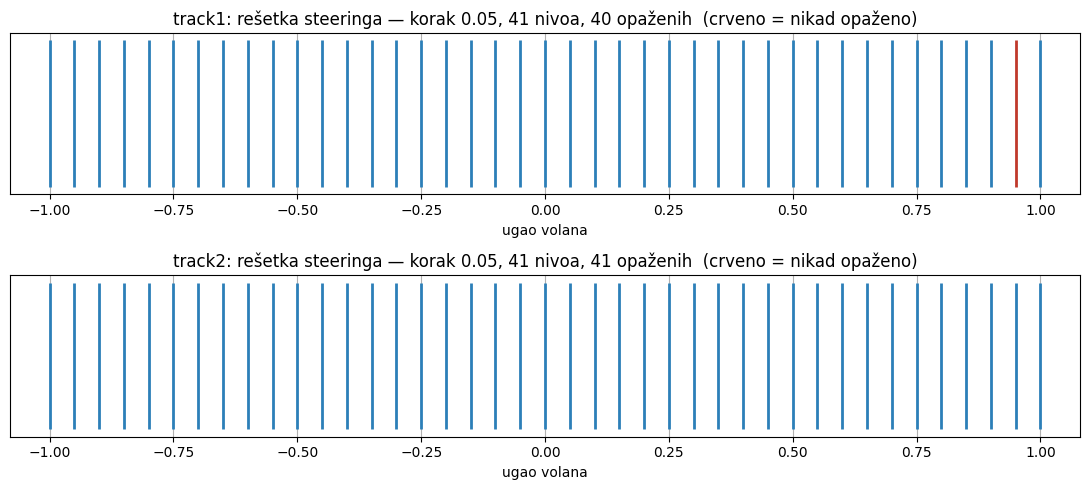

In [22]:
fig, axes = plt.subplots(2, 1, figsize=(11, 5))
for ax, (name, ds) in zip(axes, (("track1", t1), ("track2", t2))):
    p = next(p for p in profile_granularity(ds) if p.column == "steering")
    sup = np.array(p.support); unobs = set(p.unobserved_support)
    ax.vlines(sup, 0, 1, colors=["#c0392b" if float(x) in unobs else "#2c7fb8" for x in sup], lw=2)
    ax.set_yticks([]); ax.set_xlim(-1.08, 1.08)
    ax.set_title(f"{name}: rešetka steeringa — korak {p.spacing}, {len(sup)} nivoa, "
                 f"{p.n_distinct} opaženih  (crveno = nikad opaženo)")
    ax.set_xlabel("ugao volana")
fig.tight_layout(); plt.show()

**Čitanje.**

- `steering` → **diskretna**, korak 0.05, 41 nivo. Nijedna vrijednost nije van rešetke.
  (Vrijednost van rešetke bila bi **najjači pojedinačni dokaz** koji ova provjera može dati —
  značila bi da je neko računao nove brojeve, glađenjem ili interpolacijom, i upisao ih nazad.)
- track1 nikad ne koristi nivo **+0.95**, track2 koristi svih 41.
- `throttle` i `speed` → **kontinualne**, hiljade različitih vrijednosti.
- `brake` na track1 → **konstantna**: jedna jedina vrijednost u svih 10.615 redova.
  Na track2 ista kolona ima 1.708 vrijednosti. Vratićemo se na ovo u 5.3 — to je jedan od
  dva „radna primjera" cijele sekcije.

### Korak 17 — Tri hipoteze, tri različita pitanja

Sada kada znamo da je steering **diskretan**, χ² je pravi alat — i to na svom domaćem terenu:

> Za diskretnu varijablu **kategorije su same vrijednosti**. Nema binovanja, nema izbora broja
> kanti, nema granica koje neko bira. U Sekciji 3 smo morali birati ~30 kanti i to je bio izvor
> proizvoljnosti. Ovdje toga nema.

**Zašto ne KS test?** KS pretpostavlja **kontinualnu** raspodjelu. Na rešetkastim podacima ima
mnogo vezanih vrijednosti (ties) i njegova p-vrijednost naprosto nije tačna. To je i formalni
razlog zašto KS provjera iz Sekcije 3 nije bila pouzdana.

| Test | H₀ | Očekujemo | **Šta bi značila druga strana** |
|---|---|---|---|
| **T1** saglasnosti | steering je **uniforman** po 41 nivou | odbacivanje | *da NE odbacimo* → kolonu je napravio generator slučajnih brojeva |
| **T2** simetrije | P(+k) = P(−k) za svaki nivo | zavisi od staze | odbacivanje ≠ sumnjivo (vidi 5.3) |
| **T3** homogenosti | obje staze imaju **istu** raspodjelu | odbacivanje | *da NE odbacimo* → jedan snimak iskopiran i preimenovan |

Obratite pažnju na zadnju kolonu. **T1 i T3 su korisni upravo zato što očekujemo odbacivanje.**
Odbacivanje je potvrda da su podaci stvarni; neodbacivanje bi bila uzbuna.

**Rijetki nivoi i dof.** Nivoe sa očekivanom frekvencijom < 5 spajamo (isto pravilo kao M1), ali
**simetrično od repova ka centru** — jer bi asimetrično spajanje samo po sebi uvelo asimetriju
koju bi T2 onda izmjerio kao nalaz. Test bi mjerio vlastitu pripremu podataka. dof
izvještavamo **nakon** spajanja.

In [23]:
gran = {"track1": profile_granularity(t1), "track2": profile_granularity(t2)}
support = auth._steering_support(gran)
counts = {n: auth.counts_on_support(ds.df["steering"], support)
          for n, ds in (("track1", t1), ("track2", t2))}

tests = []
for n, c in counts.items():
    tests.append(auth.chi2_uniform_gof(c, support, scope=n))
    tests.append(auth.chi2_symmetry(c, support, scope=n))
tests.append(auth.chi2_homogeneity(counts["track1"], counts["track2"], support,
                                   scope="track1 vs track2"))

for r in tests:
    print(f"### {r.test_id} — {r.scope}")
    print(f"  H₀: {r.null_hypothesis}")
    print(f"  χ² = {r.statistic:,.2f}   dof = {r.dof} (spojenih kategorija: "
          f"{r.n_categories_pooled})   kritično = {r.critical_value:.2f}   p = {r.p_value:.3g}")
    print(f"  Odluka pri α={r.alpha}: {'ODBACUJEMO H₀' if r.reject_null else 'NE odbacujemo H₀'}")
    print(f"  → {r.interpretation}")
    print()

### T1_uniform_gof — track1
  H₀: steering je uniformno raspoređen po 41 nivoa rešetke — svaka vrijednost jednako vjerovatna, kako bi ih dao uniformni generator
  χ² = 264,576.53   dof = 40 (spojenih kategorija: 0)   kritično = 55.76   p = 0
  Odluka pri α=0.05: ODBACUJEMO H₀
  → ODBAČENO, kako smo i očekivali. Steering ima strukturu kakvu uniformni generator slučajnih brojeva ne proizvodi — to je dokaz PROTIV toga da je kolona izmišljena.

### T2_symmetry — track1
  H₀: raspodjela steeringa je simetrična oko nule: vozač je nivo +k koristio jednako često kao nivo −k, za svaki nivo k
  χ² = 1,078.73   dof = 18 (spojenih kategorija: 2)   kritično = 28.87   p = 1.03e-217
  Odluka pri α=0.05: ODBACUJEMO H₀
  → ODBAČENO: lijevo/desno = 1,849 / 344 (odnos 5.375) — razlika je prevelika da bi bila slučajna. Odbacivanje samo po sebi NIJE sumnjivo: ono govori da asimetrija postoji, ne odakle dolazi. Uz to, pri ovolikom uzorku χ² vidi i sasvim malu neravnotežu, pa odnos treba čitati zajedno sa p-

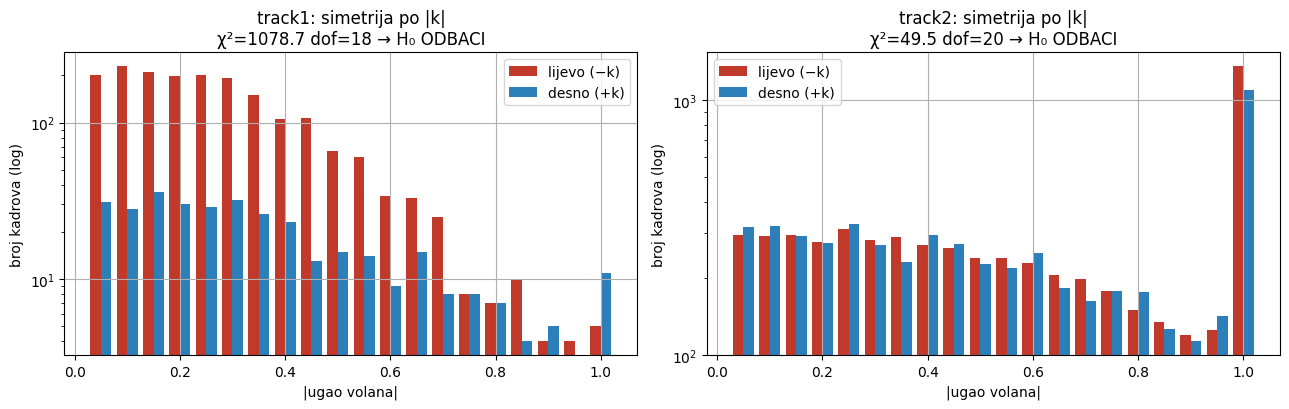

In [24]:
sup = np.asarray(support)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for ax, name in zip(axes, ("track1", "track2")):
    c = counts[name]
    lvl = sup[sup > 0]
    right = c[sup > 0]
    left = np.array([c[np.isclose(sup, -x)].sum() for x in lvl])
    ax.bar(lvl - 0.01, left, 0.02, label="lijevo (−k)", color="#c0392b")
    ax.bar(lvl + 0.01, right, 0.02, label="desno (+k)", color="#2c7fb8")
    ax.set_yscale("log")
    r = next(t for t in tests if t.test_id == "T2_symmetry" and t.scope == name)
    ax.set_title(f"{name}: simetrija po |k|\nχ²={r.statistic:.1f} dof={r.dof} → "
                 f"H₀ {'ODBACI' if r.reject_null else 'ZADRŽI'}")
    ax.set_xlabel("|ugao volana|"); ax.set_ylabel("broj kadrova (log)"); ax.legend()
fig.tight_layout(); plt.show()

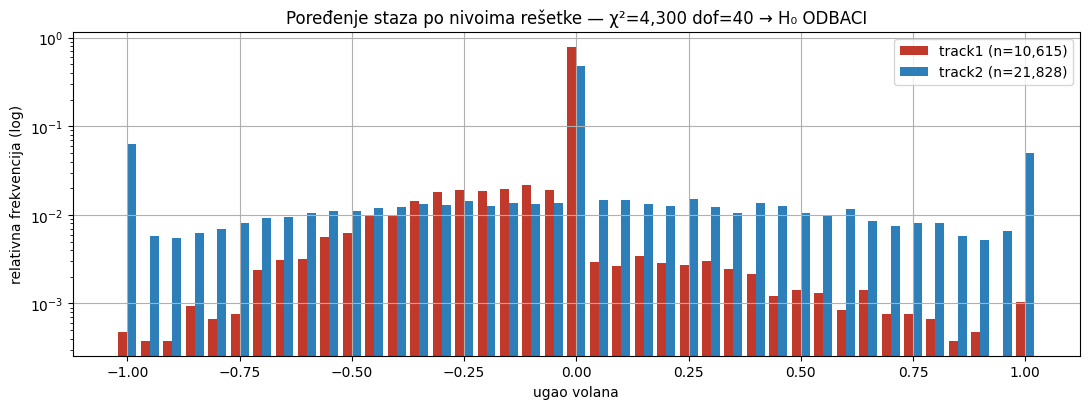

In [25]:
r3 = tests[-1]
fig, ax = plt.subplots(figsize=(11, 4.2))
for i, (name, c) in enumerate(counts.items()):
    # Relativna frekvencija, ne sirovi broj: track2 ima duplo više redova, a pitanje je
    # da li se razlikuje OBLIK raspodjele.
    ax.bar(sup + (i - 0.5) * 0.02, c / c.sum(), 0.02, label=f"{name} (n={c.sum():,.0f})",
           color={"track1": "#c0392b", "track2": "#2c7fb8"}[name])
ax.set_yscale("log")
ax.set_title(f"Poređenje staza po nivoima rešetke — χ²={r3.statistic:,.0f} dof={r3.dof} → "
             f"H₀ {'ODBACI' if r3.reject_null else 'ZADRŽI'}")
ax.set_xlabel("ugao volana"); ax.set_ylabel("relativna frekvencija (log)"); ax.legend()
fig.tight_layout(); plt.show()

**Čitanje sva tri testa.**

- **T1** je odbačen ubjedljivo na obje staze (χ² u stotinama hiljada, kritično ≈ 56). Steering
  ima strukturu koju uniformni generator ne proizvodi — dominira prava vožnja (steering = 0).
  **Ovo je dokaz PROTIV toga da je kolona izmišljena.**
- **T2** je odbačen na **obje** staze, ali to su dvije potpuno različite priče:
  - track1: odnos lijevo/desno = **5,375** — ogromna, stvarna asimetrija (vidi lijevi grafik).
  - track2: odnos = **1,052** — praktično ništa, ali pri 21.828 kadrova χ² i to vidi.

  > Ovo je jedna od najvažnijih lekcija cijele sekcije: **statistička značajnost nije isto što
  > i praktična značajnost.** Pri velikom uzorku p-vrijednost postane sitna i za trivijalan
  > efekat. Zato uz svaki test izvještavamo i **odnos**, a ne samo p.
- **T3** je odbačen (χ² ≈ 4300). Staze se stvarno različito voze → **dva različita snimka**, a
  ne jedan udvojen. Na grafiku se vidi zašto: track2 ima mnogo više punog zaokreta (±1.0,
  serpentine), track1 mnogo više malih uglova.

## 5.3 — Objašnjivo naspram sumnjivog

### Korak 18 — Nalaz bez mehanizma ne dokazuje ništa

Do sada imamo gomilu brojeva. Sad dolazi korak koji ih pretvara u nešto što se može braniti:

> **Nalaz je dokaz friziranja samo ako NEMAMO mehanizam koji ga objašnjava.**

Svaki nalaz dobija **verdikt** sa dva obavezna pravila (oba su ugrađena u kod, pa se na njih ne
može zaboraviti):

1. `explainable` **mora** imenovati mehanizam. Objašnjenje bez uzroka je samo tvrdnja.
2. Nalaz koji nosi **posljedicu** mora nositi i **mjeru**. Reći „ovo je problem" bez „evo šta
   uraditi" ostavlja čitaoca u gorem stanju nego šutnja.

Objašnjivo i štetno su **nezavisne** stvari — nalaz može biti potpuno objašnjen i **i dalje**
kvariti kasniji milestone. Dva radna primjera:

| Nalaz | Izgleda kao | Mehanizam | Verdikt | Posljedica |
|---|---|---|---|---|
| track1 `brake` ima **1** vrijednost u 10.615 redova | obrisana kolona | staza 1 je ravna petlja; vozač nijednom nije zakočio | **objašnjivo** | M1 je nad spojenim podacima rekao `brake_is_dead: false` — po stazi je **mrtva** |
| track1 lijevo/desno = **5,375** | selektivno izbačeni desni zaokreti | zatvorena petlja vožena u jednom smjeru | **objašnjivo** | ozbiljan rizik za M4: BC model vuče lijevo → **mjera:** horizontalno ogledanje slike uz promjenu znaka steeringa |

Kako razlikujemo obrisanu kolonu od nikad korištene? U brojkama izgledaju **identično**. Ono
što ih razlikuje je dokaz da pisač kolone radi — a to imamo: ista kolona na drugoj stazi ima
1.708 različitih vrijednosti.

In [26]:
out = auth.run_authenticity(("track1", "track2"))
neobj = [v for v in out.verdicts if v.classification == "unexplained"]
print(f"Nalaza ukupno: {len(out.verdicts)}   NEOBJAŠNJENIH: {len(neobj)}")
print()
for v in out.verdicts:
    print(f"[{'objašnjivo' if v.classification == 'explainable' else 'NEOBJAŠNJENO'}] {v.finding_id}")
    print(f"    nalaz     : {v.summary}")
    if v.mechanism:
        print(f"    mehanizam : {v.mechanism}")
    if v.downstream_consequence:
        print(f"    posljedica: {v.downstream_consequence}")
    if v.mitigation:
        print(f"    mjera     : {v.mitigation}")
    print()

Nalaza ukupno: 12   NEOBJAŠNJENIH: 0

[objašnjivo] track1:brake:constant
    nalaz     : track1: kolona 'brake' ima tačno jednu vrijednost u svih 10,615 redova
    mehanizam : staza 1 je ravna zatvorena petlja — vozač nijednom nije zakočio. Obrisana kolona i nikad korištena kolona izgledaju isto u brojkama; razlikuje ih to što ista kolona drugdje varira (track2: 1,708 različitih), dakle format je ispravan i pisač kolone radi
    posljedica: M1 je nad spojenim podacima prijavio brake_is_dead: false (94,6 % nula). To je artefakt spajanja — po stazi je kolona mrtva
    mjera     : kočnicu izvještavati po stazi, nikad spojeno; ne koristiti je kao ulaz za model treniran samo na stazi 1

[objašnjivo] track1:steering:unobserved_levels
    nalaz     : track1: nivoi [0.95] postoje u rešetki ali se nikad ne pojavljuju
    mehanizam : nivo koji vozač jednostavno nije upotrijebio. Da je neko brisao redove, nestajali bi cijeli opsezi vrijednosti i vidjeli bismo rupu i u vremenu — ovdje je nestao je

In [27]:
# Obećana provjera iz koraka 14: da li se ekstremno ubrzanje POKLAPA sa rupom u vremenu?
# To bi bio potpis spajanja dva snimka.
for name, ds in (("track1", t1), ("track2", t2)):
    tl = check_timeline(ds)[0]
    pl = check_plausibility(ds)[0]
    poklapanje = sorted(set(tl.gap_examples) & set(pl.outlier_indices))
    print(f"{name}: rupe na redovima {tl.gap_examples or '—'}, "
          f"posljednji red = {len(ds.df) - 1}")
    print(f"         poklapanje rupa i ekstremnog ubrzanja: {poklapanje or 'NEMA'}")

track1: rupe na redovima [10614], posljednji red = 10614
         poklapanje rupa i ekstremnog ubrzanja: NEMA


track2: rupe na redovima —, posljednji red = 21827
         poklapanje rupa i ekstremnog ubrzanja: NEMA


**Ovo je zaključni dokaz za jedinu rupu koju smo našli.**

Rupa na track1 pada na **posljednji red snimka** — to je gašenje snimača, a ne izrezan komad.
Izrezan blok iz sredine ostavio bi rupu **u sredini** *i* skok u sadržaju na spoju; ovdje
brzina i steering teku neprekidno preko nje, i nema poklapanja sa ekstremnim ubrzanjem.

In [28]:
print("Da li se M1 kalibracija za Unity mijenja?")
print()
print("ODGOVOR:", "NE" if out.calibration_unchanged else "DA")
print()
print(out.calibration_note)

Da li se M1 kalibracija za Unity mijenja?

ODGOVOR: NE

Prag |Δsteering| (P95) ponovo izračunat: 0.5500001 naspram M1 0.5500001. Robustan opseg steeringa (P1–P99): (-1.000, 1.000) naspram M1 (-1.000, 1.000). NEPROMIJENJENO. Razlog: oba broja su percentili, dakle redoslijedne statistike — čitaju se iz sortiranih vrijednosti i potpuno su nezavisne od toga da li varijablu zovemo diskretnom ili kontinualnom. Uzgred, prag je 11 koraka rešetke, što potvrđuje da pada tačno na dozvoljenu vrijednost.


**Zašto se kalibracija nije morala mijenjati.**

Oba broja koja M1 predaje Unityju su **percentili** — P95 od |Δsteering| i opseg P1–P99. A
percentil je **redoslijedna statistika**: računa se iz *sortiranih* vrijednosti. Potpuno mu je
svejedno da li varijablu zovemo diskretnom ili kontinualnom, jer sortiranje ne mari za to.

Ali — i ovo je poenta — **provjerili smo, nismo pretpostavili.** Zaključak koji zvuči očigledno
i dalje mora biti izmjeren.

Lijep detalj: prag 0.5500001 je tačno **11 koraka rešetke**. Prag pada na dozvoljenu
vrijednost, što je prijatna potvrda da je izveden iz stvarnih podataka.

## Zaključak Sekcije 5 — šta možemo tvrditi, a šta ne

**Šta smo izmjerili, po sesiji i sa imenovanom H₀ za svaki nalaz:**

| Provjera | Rezultat |
|---|---|
| monotonost vremena | ispravna, 0 narušenja, 0 neparsiranih oznaka |
| rupe u snimku | jedna (track1, 0,474 s) — **na posljednjem kadru**, dakle gašenje snimača |
| identični redovi / ponovljene slike | **0 / 0** na obje staze |
| ponovljene četvorke mjerenja | 12 i 4 — očekivano na rešetki od 41 nivoa |
| vrijednosti van rešetke | **nema nijedne** (najveći ostatak 2×10⁻⁷, sistematski zapis simulatora) |
| T1 uniformnost | odbačena ubjedljivo → kolona **nije** izmišljena generatorom |
| T3 homogenost | odbačena → **dva različita snimka**, ne jedan udvojen |
| nalaza bez objašnjenja | **0 od 12** |

**Šta iz ovoga smijemo reći:** *ne postoji dokaz manipulacije, i evo tačno kojih manipulacija
smo tražili i kako bi svaka izgledala da je bila tu.*

**Šta NE smijemo reći:** „dataset je dokazano neizmijenjen". Statistički test može samo
**odbaciti** hipotezu ili je **ne odbaciti** — nikad je dokazati. Provjera koja bi tvrdila da
dokazuje ispravnost bila bi upravo ono protiv čega se ova sekcija bori.

**Dvije ispravke koje ova sekcija vraća unazad:**

1. **Sekcija 3 je bila pogrešno specifikovana.** Steering je rešetkast, pa glatka kriva nije
   mogla odgovarati. Zaključak „koristi empirijsku raspodjelu" ostaje — sada sa tačnim
   razlogom. (Upisano u `specs/001-dataset-eda/research.md`, R1/R2.)
2. **`brake_is_dead: false` je bio artefakt spajanja.** Po stazi je kolona na track1 mrtva.
   (Upisano u `DESIGN.md` §4.4.)

**Napomena za M5:** RL agent emituje **kontinualan** steering, a ljudska referenca je
**rešetkasta**. Ako se porede direktno, svaka metrika razlike mjeri **razliku u rezoluciji
zapisa**, a ne razliku u vožnji. Agentov izlaz treba prije poređenja kvantizovati na istu
rešetku. (Upisano u `DESIGN.md` §7.)

Puni izvještaj: `results/eda/authenticity_report.md` · brojevi: `results/eda/authenticity_stats.json`